<a href="https://colab.research.google.com/github/zahradhitaaisyahputri/Dimensionality-Reduction-with-Python/blob/main/Dimensionality_Reduction_with_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Anggota Kelompok**:
1. Zahra Dhita Aisyah Putri (24523262)
2. Sifa Aulia Arroyaningrum (24523078)

## **Analisis Perilaku Penggunaan Media Sosial dan Produktivitas**

**Masalah utama** dalam kasus ini adalah bagaimana menganalisis hubungan antara penggunaan media sosial dan produktivitas pengguna berdasarkan beberapa fitur perilaku digital, seperti durasi penggunaan media sosial, waktu layar harian, jam belajar, jam tidur, jumlah notifikasi, tingkat fokus, tingkat kecanduan, dan skor produktivitas.

**Tujuan utama** dari dataset ini adalah untuk membantu memahami apakah kebiasaan penggunaan media sosial yang tinggi dapat memengaruhi produktivitas seseorang. Dataset ini juga dapat digunakan untuk melihat pola perilaku pengguna, misalnya apakah pengguna dengan tingkat kecanduan media sosial tinggi cenderung memiliki fokus dan produktivitas yang lebih rendah.

### Mengapa Dimensionality Reduction Dibutuhkan?

*   **Mempermudah Visualisasi Data**: Dataset memiliki beberapa fitur yang tidak bisa divisualisasikan secara langsung dalam satu grafik. Dengan dimensionality reduction, fitur-fitur tersebut dapat direduksi menjadi 2D atau 3D sehingga pola penyebaran data lebih mudah dilihat.
*   **Membantu Eksplorasi Cluster**: Reduksi dimensi dapat membantu melihat apakah terdapat kelompok pengguna tertentu, misalnya pengguna dengan screen time tinggi dan produktivitas rendah, pengguna dengan jam belajar tinggi dan fokus baik, atau pengguna dengan tingkat kecanduan media sosial tinggi.
*   **Mengurangi Kompleksitas Data**: Banyak fitur dalam dataset saling berkaitan, seperti waktu layar harian dan durasi penggunaan media sosial. Dimensionality reduction membantu menyederhanakan fitur-fitur tersebut menjadi komponen yang lebih ringkas tanpa menghilangkan informasi penting secara berlebihan.
*   **Menghapus Informasi yang Mirip atau Berulang**: Beberapa fitur kemungkinan membawa informasi yang hampir sama. Dengan reduksi dimensi, fitur yang memiliki pola serupa dapat dirangkum menjadi beberapa komponen utama agar analisis menjadi lebih fokus.
*   **Mencegah Overfitting Jika Digunakan untuk Modeling**: Jika semua fitur langsung digunakan dalam model Machine Learning, model bisa terlalu menyesuaikan diri dengan data latih. Dengan dimensionality reduction, jumlah fitur dapat dikurangi sehingga model menjadi lebih sederhana dan lebih mudah melakukan generalisasi pada data baru.
*   **Mempermudah Pemahaman Hubungan Media Sosial dan Produktivitas**: Dengan data yang lebih ringkas, hubungan antara kecanduan media sosial, tingkat fokus, kebiasaan tidur, jam belajar, dan produktivitas dapat lebih mudah dianalisis.

Link Dataset : https://www.kaggle.com/datasets/asifxzaman/social-media-addiction-vs-productivity-dataset

In [15]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

df_train = pd.read_csv('/content/social_media_productivity_6000.csv')

display(df_train.head())
df_train.info()

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,Medium,28.49
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,Medium,18.54
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,Low,68.52
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,Medium,27.82
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,Low,51.09


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    5880 non-null   float64
 1   daily_screen_time      5880 non-null   float64
 2   social_media_hours     5880 non-null   float64
 3   study_hours            5880 non-null   float64
 4   sleep_hours            5880 non-null   float64
 5   notifications_per_day  5880 non-null   float64
 6   focus_score            5880 non-null   float64
 7   addiction_level        5880 non-null   object 
 8   productivity_score     5880 non-null   float64
dtypes: float64(8), object(1)
memory usage: 422.0+ KB


In [16]:
# Memilih fitur numerik
features = [
    'age',
    'daily_screen_time',
    'social_media_hours',
    'study_hours',
    'sleep_hours',
    'notifications_per_day',
    'focus_score',
    'productivity_score'
]

X_processed = df_train[features]
y_processed = df_train['addiction_level']

# Mengatasi missing value jika ada
X_processed = X_processed.fillna(X_processed.mean())

# Standarisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_processed)

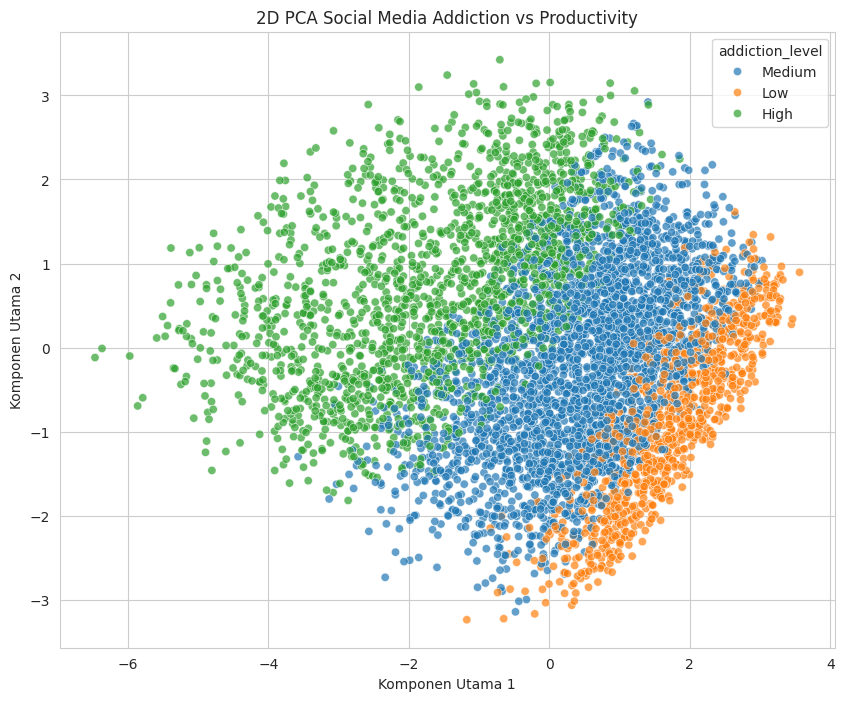

Rasio varians Komponen Utama 1: 0.35
Rasio varians Komponen Utama 2: 0.18
Total rasio varians: 0.53


In [17]:
# PCA untuk reduksi dimensi menjadi 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Membuat DataFrame hasil PCA
df_pca = pd.DataFrame(
    data=X_pca,
    columns=['principal_component_1', 'principal_component_2']
)

df_pca['addiction_level'] = y_processed

# Visualisasi PCA
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_pca,
    x='principal_component_1',
    y='principal_component_2',
    hue='addiction_level',
    palette='tab10',
    alpha=0.7
)

plt.title('2D PCA Social Media Addiction vs Productivity')
plt.xlabel('Komponen Utama 1')
plt.ylabel('Komponen Utama 2')
plt.grid(True)
plt.show()

print(f"Rasio varians Komponen Utama 1: {pca.explained_variance_ratio_[0]:.2f}")
print(f"Rasio varians Komponen Utama 2: {pca.explained_variance_ratio_[1]:.2f}")
print(f"Total rasio varians: {pca.explained_variance_ratio_.sum():.2f}")

### **Makna hasil PCA 2D**:

Berdasarkan hasil PCA 2D, data yang awalnya memiliki beberapa fitur numerik berhasil direduksi menjadi dua komponen utama, yaitu `principal_component_1` dan `principal_component_2`. Setiap titik pada grafik mewakili satu pengguna, sedangkan warna pada titik menunjukkan kategori `addiction_level`.

Komponen utama pertama menjelaskan sekitar **35%** variasi data, sedangkan komponen utama kedua menjelaskan sekitar **18%** variasi data. Jika dijumlahkan, PCA 2D mampu menjelaskan sekitar **53%** informasi dari data asli. Artinya, dua komponen utama sudah cukup membantu memberikan gambaran umum pola data, meskipun masih ada sebagian informasi lain yang tidak ditampilkan dalam visualisasi 2D.

Pada grafik PCA 2D, pola penyebaran data dapat digunakan untuk melihat apakah pengguna dengan tingkat kecanduan media sosial yang sama cenderung berada pada area yang berdekatan. Jika titik dengan warna yang sama terlihat mengelompok, berarti pengguna dengan `addiction_level` yang sama memiliki karakteristik perilaku yang mirip.

Namun, jika titik dari beberapa kategori seperti `Low`, `Medium`, dan `High` masih saling bercampur, berarti tingkat kecanduan media sosial belum dapat dipisahkan secara jelas hanya menggunakan dua komponen utama PCA. Hal ini wajar karena PCA bekerja secara linear dan lebih fokus untuk merangkum variasi terbesar dari data, bukan untuk membentuk cluster yang benar-benar terpisah.

Secara keseluruhan, PCA 2D berguna untuk melihat gambaran umum hubungan antara penggunaan media sosial dan produktivitas. Visualisasi ini membantu memahami pola awal data, tetapi untuk melihat cluster yang lebih jelas, metode t-SNE dapat digunakan sebagai pembanding.

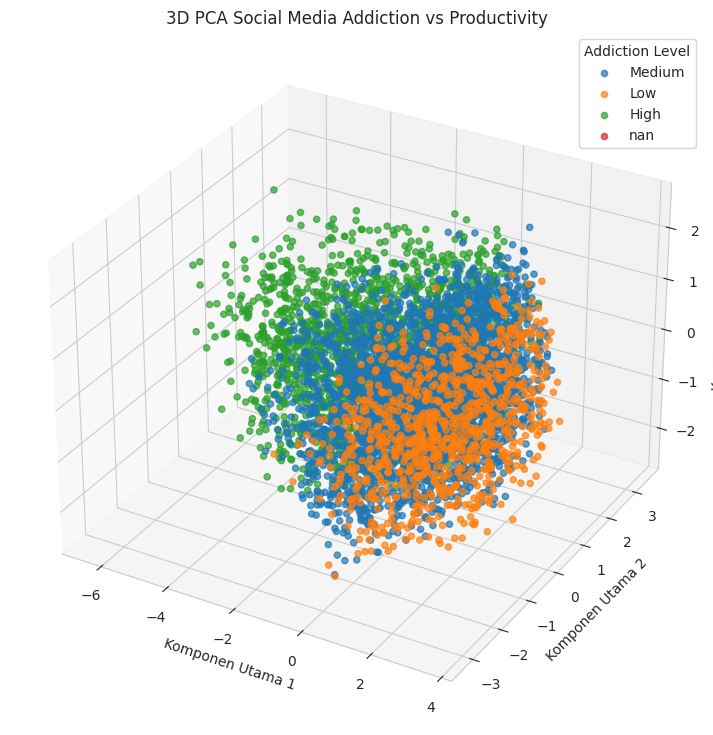

Rasio varians Komponen Utama 1: 0.35
Rasio varians Komponen Utama 2: 0.18
Rasio varians Komponen Utama 3: 0.13
Total rasio varians PCA 3D: 0.66


In [18]:
# PCA untuk reduksi dimensi menjadi 3D
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# Membuat DataFrame hasil PCA 3D
df_pca_3d = pd.DataFrame(
    data=X_pca_3d,
    columns=[
        'principal_component_1',
        'principal_component_2',
        'principal_component_3'
    ]
)

df_pca_3d['addiction_level'] = y_processed

# Visualisasi PCA 3D
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Membuat warna berdasarkan addiction_level
categories = df_pca_3d['addiction_level'].unique()

for category in categories:
    data_category = df_pca_3d[df_pca_3d['addiction_level'] == category]

    ax.scatter(
        data_category['principal_component_1'],
        data_category['principal_component_2'],
        data_category['principal_component_3'],
        label=category,
        alpha=0.7
    )

ax.set_title('3D PCA Social Media Addiction vs Productivity')
ax.set_xlabel('Komponen Utama 1')
ax.set_ylabel('Komponen Utama 2')
ax.set_zlabel('Komponen Utama 3')

ax.legend(title='Addiction Level')
plt.show()

# Menampilkan rasio varians PCA 3D
print(f"Rasio varians Komponen Utama 1: {pca_3d.explained_variance_ratio_[0]:.2f}")
print(f"Rasio varians Komponen Utama 2: {pca_3d.explained_variance_ratio_[1]:.2f}")
print(f"Rasio varians Komponen Utama 3: {pca_3d.explained_variance_ratio_[2]:.2f}")
print(f"Total rasio varians PCA 3D: {pca_3d.explained_variance_ratio_.sum():.2f}")

### **Makna Hasil PCA 3D**

Berdasarkan hasil PCA 3D, data berhasil direduksi dari beberapa fitur numerik menjadi tiga komponen utama, yaitu `principal_component_1`, `principal_component_2`, dan `principal_component_3`.

Komponen utama pertama menjelaskan sekitar **35%** variasi data, komponen utama kedua sekitar **18%**, dan komponen utama ketiga sekitar **13%**. Jika dijumlahkan, PCA 3D mampu menjelaskan sekitar **66%** informasi dari data asli. Artinya, tiga komponen utama sudah cukup mewakili sebagian besar pola dalam dataset, meskipun masih ada sebagian informasi lain yang tidak ditampilkan.

Dari visualisasi 3D, titik-titik data merepresentasikan pengguna berdasarkan pola penggunaan media sosial dan produktivitasnya. Warna pada grafik menunjukkan kategori `addiction_level`. Jika titik dengan warna yang sama terlihat berdekatan, berarti pengguna dengan tingkat kecanduan yang sama memiliki karakteristik yang mirip.

Namun, jika titik dari kategori `Low`, `Medium`, dan `High` masih saling bercampur, maka tingkat kecanduan media sosial belum dapat dipisahkan secara sangat jelas hanya dengan PCA. Hal ini wajar karena PCA bersifat linear, sehingga lebih cocok untuk melihat gambaran umum data, bukan untuk membentuk cluster yang benar-benar terpisah.

Secara keseluruhan, PCA 3D membantu memberikan visualisasi yang lebih informatif dibandingkan PCA 2D karena menambahkan satu komponen utama lagi. Dengan tambahan komponen ketiga, informasi yang ditampilkan menjadi lebih banyak, sehingga pola penyebaran data dapat diamati dengan lebih baik.

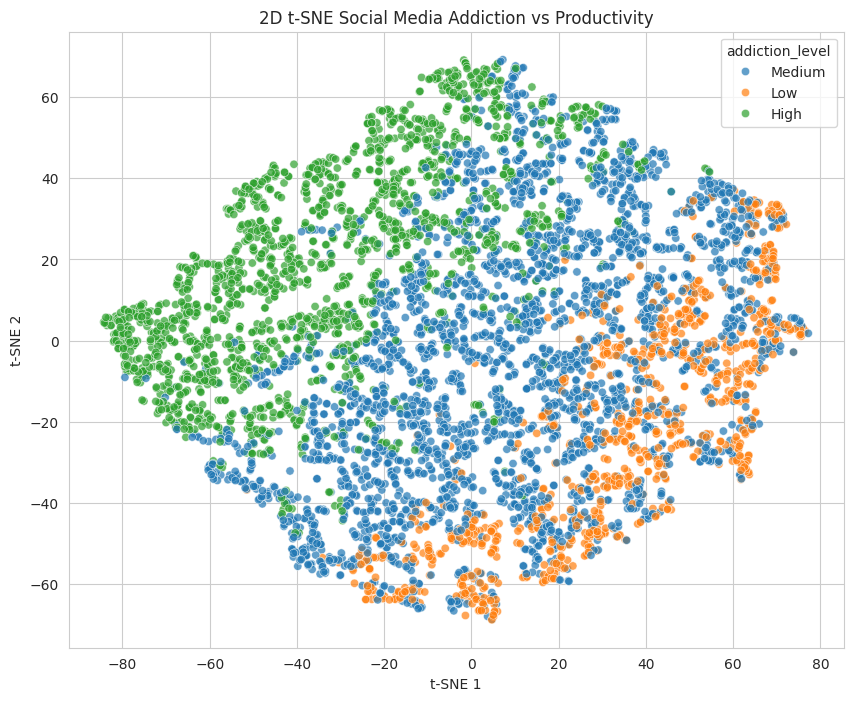

In [19]:
# t-SNE untuk reduksi dimensi menjadi 2D
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    max_iter=1000
)

X_tsne = tsne.fit_transform(X_scaled)

# Membuat DataFrame hasil t-SNE
df_tsne = pd.DataFrame(
    data=X_tsne,
    columns=['tsne_1', 'tsne_2']
)

df_tsne['addiction_level'] = y_processed

# Visualisasi t-SNE
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_tsne,
    x='tsne_1',
    y='tsne_2',
    hue='addiction_level',
    palette='tab10',
    alpha=0.7
)

plt.title('2D t-SNE Social Media Addiction vs Productivity')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True)
plt.show()

### **Pola atau Cluster yang Terbentuk**:

t-SNE digunakan untuk mereduksi data menjadi 2 dimensi agar pola atau cluster pada dataset lebih mudah dilihat. Metode ini bekerja dengan mempertahankan kemiripan antar data, sehingga data yang memiliki karakteristik mirip akan diletakkan berdekatan dalam visualisasi.

Pada dataset **Social Media Addiction vs Productivity**, setiap titik pada grafik t-SNE mewakili satu pengguna. Warna pada titik menunjukkan kategori `addiction_level`, sehingga visualisasi ini dapat membantu melihat apakah pengguna dengan tingkat kecanduan media sosial tertentu membentuk kelompok atau cluster.

Jika pada hasil visualisasi terlihat titik-titik dengan warna yang sama saling berdekatan, maka hal tersebut menunjukkan bahwa pengguna dengan tingkat kecanduan yang sama memiliki pola perilaku yang mirip. Misalnya, pengguna dengan `social_media_hours` tinggi, `daily_screen_time` tinggi, `focus_score` rendah, dan `productivity_score` rendah dapat membentuk kelompok tertentu.

Namun, jika titik dari beberapa kategori `addiction_level` masih saling bercampur, berarti pola tingkat kecanduan media sosial belum terpisah secara sempurna. Hal ini menunjukkan bahwa kecanduan media sosial dan produktivitas kemungkinan dipengaruhi oleh kombinasi beberapa fitur, bukan hanya satu faktor saja.

## **Analisis Singkat**

### **Perbedaan Hasil PCA dan t-SNE**

* **PCA** menampilkan data dalam bentuk 2D atau 3D dengan cara mencari komponen utama yang paling banyak menyimpan informasi dari fitur asli. Pada dataset ini, PCA membantu merangkum fitur seperti `daily_screen_time`, `social_media_hours`, `study_hours`, `sleep_hours`, `notifications_per_day`, `focus_score`, dan `productivity_score` menjadi beberapa komponen utama.

* Hasil PCA lebih mudah dijelaskan karena memiliki nilai **explained variance ratio**. Nilai ini menunjukkan seberapa besar informasi dari data asli yang berhasil dirangkum oleh komponen utama. Jika total varians PCA belum terlalu besar, berarti masih ada sebagian informasi dari fitur asli yang tidak terlihat pada visualisasi.

* Pada visualisasi PCA, pola data dapat terlihat secara umum, tetapi pemisahan antar tingkat **addiction_level** belum tentu terlihat jelas. Hal ini karena PCA bekerja secara linear, sehingga kurang mampu menangkap pola data yang lebih kompleks.

* **t-SNE** menghasilkan visualisasi yang lebih fokus pada kemiripan antar data. Data yang memiliki karakteristik mirip akan ditempatkan berdekatan, sedangkan data yang berbeda akan ditempatkan lebih jauh.

* Pada hasil t-SNE, pola cluster atau kelompok pengguna biasanya lebih mudah terlihat dibandingkan PCA. Misalnya, pengguna dengan tingkat kecanduan media sosial tinggi dapat terlihat membentuk kelompok tertentu jika memiliki pola perilaku yang mirip, seperti durasi media sosial tinggi, fokus rendah, dan produktivitas rendah.

### **Metode yang Lebih Sesuai untuk Kasus Ini**

Metode yang lebih sesuai untuk kasus **analisis kecanduan media sosial dan produktivitas** adalah **t-SNE**, terutama jika tujuan utamanya adalah **visualisasi data dan eksplorasi cluster**.

Alasannya, dataset ini berisi perilaku pengguna yang kemungkinan memiliki hubungan tidak linear. Produktivitas seseorang tidak hanya dipengaruhi oleh durasi penggunaan media sosial, tetapi juga oleh faktor lain seperti jam belajar, jam tidur, jumlah notifikasi, tingkat fokus, dan tingkat kecanduan media sosial. Karena hubungan antar fitur tersebut cukup kompleks, t-SNE lebih cocok digunakan untuk melihat pola pengelompokan data secara visual.

Selain itu, t-SNE lebih baik dalam menampilkan data yang memiliki karakteristik mirip agar terlihat saling berdekatan. Hal ini membantu analisis untuk melihat apakah pengguna dengan **addiction_level** tertentu cenderung membentuk cluster atau masih bercampur dengan kategori lain.

Namun, PCA tetap berguna sebagai tahap awal karena hasilnya lebih sederhana dan mudah dijelaskan melalui nilai **explained variance ratio**. PCA cocok untuk melihat gambaran umum data, sedangkan t-SNE lebih sesuai untuk melihat pola cluster pengguna secara lebih jelas.

Dengan demikian, untuk kasus ini **t-SNE lebih sesuai digunakan sebagai metode visualisasi cluster**, sedangkan **PCA lebih sesuai digunakan untuk reduksi fitur awal dan interpretasi umum data**.